In [71]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

In [72]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [73]:
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

In [74]:
class Generator(nn.Module):

    def __init__(self, z_dim=100, num_classes=10):

        super().__init__()

        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.model = nn.Sequential(

            nn.ConvTranspose2d(z_dim + num_classes,256,4,1,0),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64,1,4,2,1),
            nn.Tanh()
        )

    def forward(self,z,labels):

        c = self.label_emb(labels)

        x = torch.cat([z,c],1)

        x = x.unsqueeze(2).unsqueeze(3)

        img = self.model(x)

        return img

In [75]:
class Discriminator(nn.Module):

    def __init__(self,num_classes=10):

        super().__init__()

        self.label_emb = nn.Embedding(num_classes,num_classes)

        self.model = nn.Sequential(

            nn.Conv2d(1 + num_classes,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256,1,4,1,0),
            nn.Sigmoid()
        )

    def forward(self,img,labels):

        c = self.label_emb(labels)

        c = c.unsqueeze(2).unsqueeze(3)

        c = c.repeat(1,1,32,32)

        x = torch.cat([img,c],1)

        return self.model(x).view(-1,1)

In [76]:
z_dim = 100

G = Generator(z_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

opt_G = torch.optim.Adam(G.parameters(),lr=0.0002,betas=(0.5,0.999))
opt_D = torch.optim.Adam(D.parameters(),lr=0.0002,betas=(0.5,0.999))

In [77]:
fixed_noise = torch.randn(16,z_dim).to(device)
fixed_labels = torch.arange(0,16)%10
fixed_labels = fixed_labels.to(device)

In [78]:
epochs = 8

snapshots = []

for epoch in range(epochs):

    for real,labels in loader:

        real = real.to(device)
        labels = labels.to(device)

        batch = real.size(0)

        real_targets = torch.ones(batch,1).to(device)
        fake_targets = torch.zeros(batch,1).to(device)

        # Train Discriminator

        noise = torch.randn(batch,z_dim).to(device)
        fake_labels = torch.randint(0,10,(batch,),device=device)

        fake = G(noise,fake_labels)

        loss_real = criterion(D(real,labels),real_targets)
        loss_fake = criterion(D(fake.detach(),fake_labels),fake_targets)

        loss_D = loss_real + loss_fake

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator

        loss_G = criterion(D(fake,fake_labels),real_targets)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print("Epoch:",epoch+1)

    G.eval()

    with torch.no_grad():
        fake = G(fixed_noise,fixed_labels).cpu()
        snapshots.append(fake)

    G.train()

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8


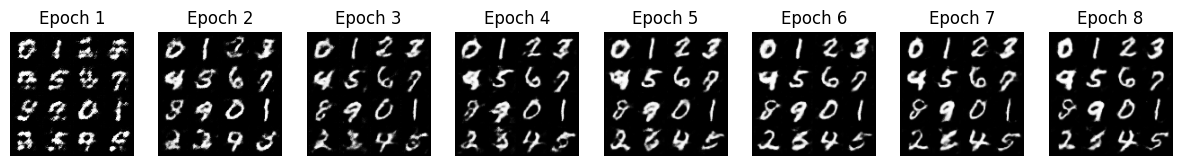

In [79]:
fig,axs = plt.subplots(1,len(snapshots),figsize=(15,3))

for i,img in enumerate(snapshots):

    grid = make_grid(img,nrow=4,normalize=True)

    axs[i].imshow(grid.permute(1,2,0))
    axs[i].axis("off")
    axs[i].set_title(f"Epoch {i+1}")

plt.show()

In [80]:
G.eval()

noise = torch.randn(16,100).to(device)

labels = torch.full((16,),8,dtype=torch.long).to(device)

with torch.no_grad():

    fake = G(noise,labels).cpu()

(np.float64(-0.5), np.float64(137.5), np.float64(137.5), np.float64(-0.5))

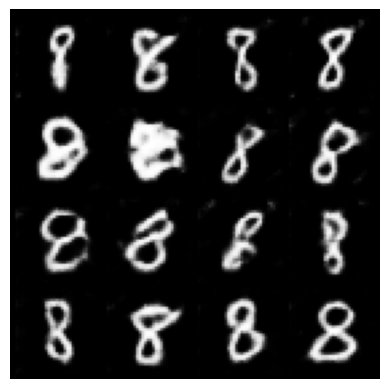

In [81]:
grid = make_grid(fake,nrow=4,normalize=True)

plt.imshow(grid.permute(1,2,0))
plt.axis("off")

(np.float64(-0.5), np.float64(137.5), np.float64(137.5), np.float64(-0.5))

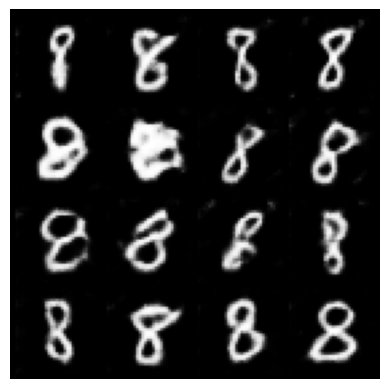

In [82]:
grid = make_grid(fake,nrow=4,normalize=True)

plt.imshow(grid.permute(1,2,0))
plt.axis("off")